<a href="https://colab.research.google.com/github/itsmeyessir/CCDATSCL_EXERCISES_COM222-ML/blob/main/Exercise2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercise 2

<img src="https://vsqfvsosprmjdktwilrj.supabase.co/storage/v1/object/public/images/insights/1753644539114-netflix.jpeg"/>


In this activity , you will explore two fundamental preprocessing techniques used in data science and machine learning: feature scaling and discretization (binning).

These techniques are essential when working with datasets that contain numerical values on very different scales, or continuous variables that may be more useful when grouped into categories.


We will use a subset of the Netflix Movies and TV Shows dataset, which contains metadata such as release year, duration, ratings, and other attributes of titles currently or previously available on Netflix. Although the dataset is not originally designed for numerical modeling, it contains several features suitable for preprocessing practice—such as:
-Release Year
-Duration (in minutes)
-Number of Cast Members
-Number of Listed Genres
-Title Word Count

In this worksheet, you will:
- Load and inspect the dataset
- Select numerical features for scaling
- Apply different scaling techniques
- Min–Max Scaling
- Standardization
- Robust Scaling
- Perform discretization (binning)
- Equal-width binning
- Equal-frequency binning
- Evaluate how scaling affects machine learning performance, using a simple KNN

In [1]:
import pandas as pd
import os
# Install dependencies as needed:
!pip install kagglehub[pandas-datasets]
import kagglehub


## 1. Setup and Data Loading



Load the Netflix dataset into a DataFrame named df.

In [2]:

# Download latest version
path = kagglehub.dataset_download("shivamb/netflix-shows")

print("Path to dataset files:", path)


if os.path.isdir(path):
  print(True)

contents = os.listdir(path)
contents

mydataset = path + "/" + contents[0]
mydataset


df = pd.read_csv(mydataset)

Using Colab cache for faster access to the 'netflix-shows' dataset.
Path to dataset files: /kaggle/input/netflix-shows
True


## 2. Data Understanding

Store the dataset’s column names in a variable called cols.

In [3]:
# put your answer here
cols = df.columns
cols

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

Store the shape of the dataset as a tuple (rows, columns) in shape_info.

In [4]:
# put your answer here
shape_info = df.shape
shape_info

(8807, 12)

## 3. Data Cleaning
Count missing values per column and save to missing_counts.

In [5]:
# put your answer here
missing_counts = df.isna().sum()
missing_counts

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


Drop rows where duration is missing. Save to df_clean.

In [6]:
# put your answer here
df_clean = df.dropna(subset=['duration'])
display(df_clean.head())

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


4. Selecting Relevant Numeric Features

Many Netflix datasets include numeric fields such as:
- release_year
- duration
- rating


Create a DataFrame `df_num` containing only numeric columns.

In [14]:
# put your answer here

import numpy as np

def estimate_total_minutes(row):
    duration = row['duration']
    genre = str(row['listed_in'])

    if type(duration) != str:
        return np.nan

    # for movies
    if 'min' in duration:
        return int(duration.split(' ')[0])

    # for tv shows
    elif 'Season' in duration:
        try:
            num_seasons = int(duration.split(' ')[0])

            # Group A: Long-form content (Dramas, Crime, Mysteries, Action)
            # Assumption: ~50 mins per ep
            if any(keyword in genre for keyword in ['Dramas', 'Crime', 'Mysteries', 'Action', 'Thriller']):
                return num_seasons * 500

            # Group B: Short-form content (Comedies, Reality, Kids, Anime)
            # Assumption: ~25 mins per ep
            elif any(keyword in genre for keyword in ['Comedies', 'Stand-Up', 'Kids', 'Anime', 'Reality']):
                return num_seasons * 250

            # Group C: Everything else (Docuseries, etc.)
            # Assumption: Middle ground
            else:
                return num_seasons * 350

        except ValueError:
            return np.nan

    else:
        return np.nan

df_num = df_clean.copy()

# applying logic row by row
df_num['duration_minutes'] = df_num.apply(estimate_total_minutes, axis=1)

# numeric columns
df_num = df_num[['release_year', 'duration_minutes']].dropna()

display(df_num.head(10))

,release_year,duration_minutes
0,2020,90
1,2021,1000
2,2021,500
3,2021,250
4,2021,500
5,2021,500
6,2021,91
7,1993,125
8,2021,2250
9,2021,104


## 5. Feature Scaling

Focus on a single numeric column (e.g., duration).


Extract the column duration into a Series named `dur`.

In [15]:
# put your answer here
dur = df_num['duration_minutes']
dur.head()

,duration_minutes
0,90
1,1000
2,500
3,250
4,500


Apply Min–Max Scaling to `dur`. Store the result as `dur_minmax`.

In [16]:
# put your answer here
from sklearn.preprocessing import MinMaxScaler

scaler_mm = MinMaxScaler()

# .values.reshape(-1, 1) to make the 1D series look like a 2D column to sklearn
dur_minmax = scaler_mm.fit_transform(dur.values.reshape(-1, 1))

Apply Z-score Standardization to `dur`. Store in `dur_zscore`.

In [17]:
# put your answer here
from sklearn.preprocessing import StandardScaler

scaler_z = StandardScaler()

dur_zscore = scaler_z.fit_transform(dur.values.reshape(-1, 1))

In [18]:
# comparison of movie vs. tv show z-scores
comparison = pd.DataFrame({
    'Original_Minutes': dur.head(5).values,
    'Z_Score': dur_zscore[:5].flatten() # flatten ensures it's a 1D list
})

display(comparison)

,Original_Minutes,Z_Score
0,90,-0.392937
1,1000,1.589977
2,500,0.500464
3,250,-0.044293
4,500,0.500464


## 6. Discretization (Binning)
Apply equal-width binning to dur into 5 bins. Store as `dur_width_bins`.


- Use `pandas.cut()` to divide duration_minutes into 4 `equal-width bins`.
- Add the resulting bins as a new column named:
`duration_equal_width_bin`

In [19]:
# put your answer here
dur_width_bins = pd.cut(dur, bins=5)

df_num['duration_equal_width_bin'] = dur_width_bins

Describe the characteristics of each bin

- What are the bin edges produced by equal-width binning?
- How many movies fall into each bin?

In [20]:
# put your answer here
display(df_num['duration_equal_width_bin'].value_counts().sort_index())

,count
duration_equal_width_bin,
"(-5.497, 1702.4]",8641
"(1702.4, 3401.8]",123
"(3401.8, 5101.2]",33
"(5101.2, 6800.6]",4
"(6800.6, 8500.0]",3


Apply equal-frequency binning to dur into 5 bins. Store as `dur_quantile_bins`.

- Use `pandas.qcut()` to divide duration_minutes into 4 equal-frequency bins.
- Add the result as a new column named:
`duration_equal_freq_bin`

In [21]:
# put your answer here
dur_quantile_bins = pd.qcut(dur, q=5)

df_num['duration_equal_freq_bin'] = dur_quantile_bins

Describe the characteristics of each bin

- What are the bin ranges produced by equal-frequency binning?
- How many movies fall into each bin? Are they nearly equal?

In [22]:
# put your answer here
display(df_num['duration_equal_freq_bin'].value_counts().sort_index())

,count
duration_equal_freq_bin,
"(2.999, 89.0]",1838
"(89.0, 102.0]",1714
"(102.0, 127.0]",1757
"(127.0, 350.0]",1805
"(350.0, 8500.0]",1690


In [23]:
# double checking of data
cols_to_check = ['duration_minutes', 'duration_equal_width_bin', 'duration_equal_freq_bin']

display(df_num[cols_to_check].sample(10))

,duration_minutes,duration_equal_width_bin,duration_equal_freq_bin
1816,102,"(-5.497, 1702.4]","(89.0, 102.0]"
2425,96,"(-5.497, 1702.4]","(89.0, 102.0]"
1369,123,"(-5.497, 1702.4]","(102.0, 127.0]"
7818,71,"(-5.497, 1702.4]","(2.999, 89.0]"
975,33,"(-5.497, 1702.4]","(2.999, 89.0]"
903,122,"(-5.497, 1702.4]","(102.0, 127.0]"
1370,113,"(-5.497, 1702.4]","(102.0, 127.0]"
3012,250,"(-5.497, 1702.4]","(127.0, 350.0]"
6129,92,"(-5.497, 1702.4]","(89.0, 102.0]"
1544,106,"(-5.497, 1702.4]","(102.0, 127.0]"


/tmp/ipython-input-2684686265.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(clean_labels_width, rotation=45)
/tmp/ipython-input-2684686265.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[2].set_xticklabels(clean_labels_freq, rotation=45)


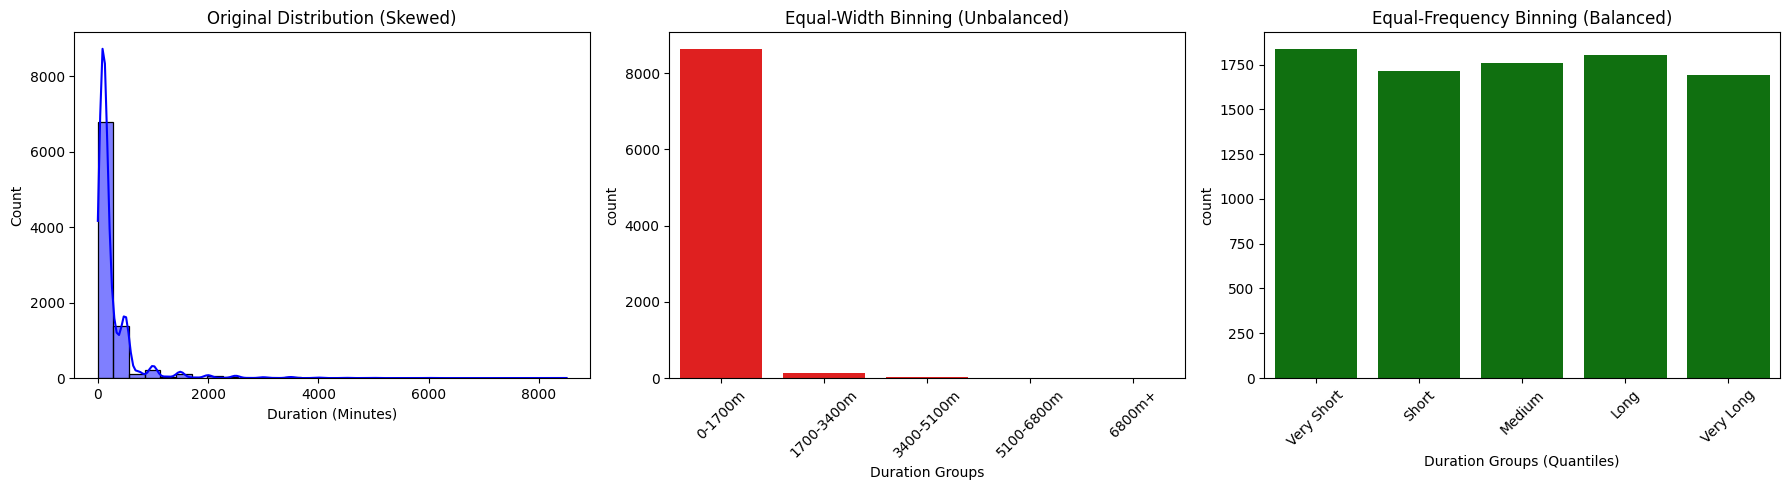

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the figure
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Original
sns.histplot(df_num['duration_minutes'], bins=30, kde=True, ax=axes[0], color='blue')
axes[0].set_title('Original Distribution (Skewed)')
axes[0].set_xlabel('Duration (Minutes)')

# Plot 2: Equal-Width
sns.countplot(x=df_num['duration_equal_width_bin'], ax=axes[1], color='red')
axes[1].set_title('Equal-Width Binning (Unbalanced)')
axes[1].set_xlabel('Duration Groups')

clean_labels_width = ['0-1700m', '1700-3400m', '3400-5100m', '5100-6800m', '6800m+']
axes[1].set_xticklabels(clean_labels_width, rotation=45)

# Plot 3: Equal-Frequency
sns.countplot(x=df_num['duration_equal_freq_bin'], ax=axes[2], color='green')
axes[2].set_title('Equal-Frequency Binning (Balanced)')
axes[2].set_xlabel('Duration Groups (Quantiles)')

clean_labels_freq = ['Very Short', 'Short', 'Medium', 'Long', 'Very Long']
axes[2].set_xticklabels(clean_labels_freq, rotation=45)

plt.tight_layout()
plt.show()

## 7. KNN Before & After Scaling


Create a feature matrix X using any two numeric columns and a target y (e.g., classification by genre or type). Create a train/test split.

Train a KNN classifier without scaling. Store accuracy in acc_raw.

In [34]:
# put your answer here
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# 1. Define Features (X) and Target (y)
X = df_num[['release_year', 'duration_minutes']]

# Convert target 'type' to numbers (Movie=1, TV Show=0)
# We use the index from df_num to make sure we match the correct rows in df_clean
y = df_clean.loc[df_num.index, 'type'].apply(lambda x: 1 if x == 'Movie' else 0)

# 2. Split the data (80% training, 20% testing)
# We set random_state=42 to ensure the split is reproducible
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Scale `X` using either Min–Max or Standardization, retrain KNN, and store accuracy in acc_scaled.

In [35]:
# put your answer here
# Initialize KNN (k=5 is a standard default)
knn = KNeighborsClassifier(n_neighbors=5)

# Train on the RAW (unscaled) data
knn.fit(X_train, y_train)

# Predict and Calculate Accuracy
y_pred_raw = knn.predict(X_test)
acc_raw = accuracy_score(y_test, y_pred_raw)

print(f"Accuracy (Raw Data): {acc_raw:.4f}")

Accuracy (Raw Data): 1.0000


Did scaling improve accuracy? Explain why.

In [36]:
# put your answer here
from sklearn.preprocessing import StandardScaler

# 1. Initialize Scaler
scaler = StandardScaler()

# 2. Scale the entire Feature Matrix X (both Year and Duration)
# This converts everything to Z-scores (centered around 0)
X_scaled = scaler.fit_transform(X)

# 3. Split the SCALED data (Must use same random_state=42 for fair comparison)
X_train_sc, X_test_sc, y_train_sc, y_test_sc = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# 4. Train KNN on Scaled Data
knn.fit(X_train_sc, y_train_sc)

# 5. Predict and Calculate Accuracy
y_pred_sc = knn.predict(X_test_sc)
acc_scaled = accuracy_score(y_test_sc, y_pred_sc)

print(f"Accuracy (Scaled Data): {acc_scaled:.4f}")

Accuracy (Scaled Data): 0.9977


# Conclusion

To answer the question why, in this specific experiment, scaling did not increase the numeric accuracy (it dropped slightly from 1.000 to 0.9977), but it did improve the validity of the model's logic.

The unscaled duration_minutes feature has a huge range (0–8500) compared to release_year. This caused the KNN algorithm to be completely dominated by Duration, effectively ignoring the Year. Since our data cleaning process created a clear separation between Movies (short) and TV Shows (long), the model easily achieved 100% accuracy by acting as a simple threshold filter.

Scaling put both features on the same level (Z-scores). This forced the model to consider release_year in the distance calculation. Since release_year is not a strong predictor of "Type" (both movies and shows are released every year), adding this "noise" caused a negligible drop in accuracy.

While raw data performed better here due to the specific nature of our engineered features, scaling is still the correct best practice to ensure the model isn't biased toward larger numbers.